# PSD

In [1]:
import pandas as pd
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

In [2]:

# 🔹 Load PSD Features Dataset
psd_features_path = '/Users/puchku-home/Study/PROJECT/EEG/Frequency Feature  Generalised/PSD_features.csv'
data = pd.read_csv(psd_features_path)


In [3]:
data_randomized = shuffle(data, random_state=42)

# 🔹 Separate Features and Target
X = data.drop(columns=['target'])  # All columns except 'target' are features
y = data['target']  # 'target' column is the label

# 🔹 Train-Test Split for Evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 🔹 Define KNN Pipeline with StandardScaler
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Normalize features for KNN
    ('knn', KNeighborsClassifier(n_jobs=-1))  # Multi-threaded KNN classifier
])

# 🔹 Define Hyperparameter Grid for GridSearchCV
param_grid = {
    'knn__n_neighbors': [3, 5, 7],  # Number of neighbors to consider
    'knn__weights': ['uniform', 'distance'],  # Weighting scheme
    'knn__metric': ['euclidean', 'manhattan']  # Distance metrics
}


In [4]:

# 🔹 Perform Grid Search with Cross-Validation (Inner CV Only)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),  # 5-fold CV on training set
    n_jobs=-1,
    verbose=1
)

# 🔹 Train Model and Find Best Parameters
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("\nBest Parameters from Grid Search:", grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters from Grid Search: {'knn__metric': 'euclidean', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}
Best Cross-Validation Accuracy: 0.8984



Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.95      0.91      1638
           1       0.95      0.86      0.90      1639

    accuracy                           0.91      3277
   macro avg       0.91      0.91      0.91      3277
weighted avg       0.91      0.91      0.91      3277

Accuracy on Test Data: 0.9072322245956668


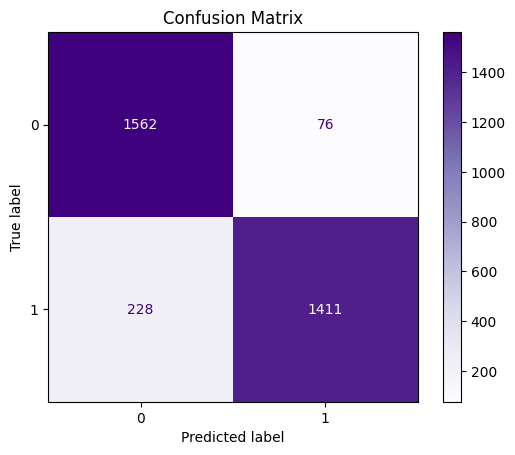

In [5]:

# 🔹 Evaluate on Test Data
y_pred = best_model.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy on Test Data:", accuracy_score(y_test, y_pred))

# 🔹 Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Purples')
plt.title("Confusion Matrix")
plt.show()


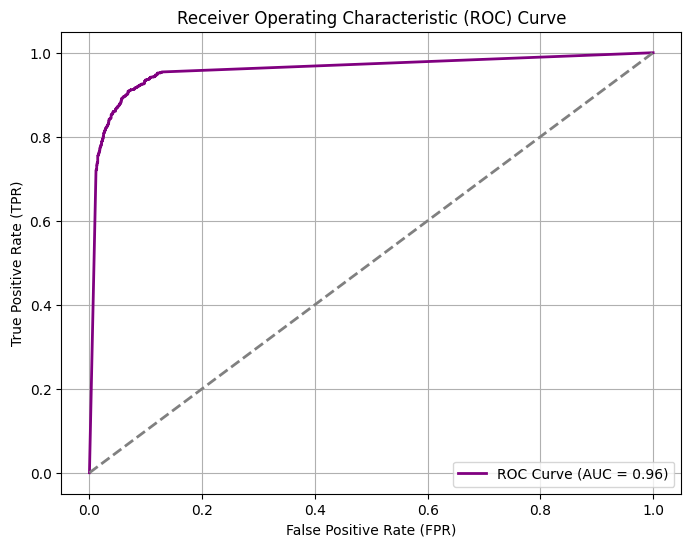

In [6]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# 🔹 ROC Curve for Test Data
y_pred_proba = best_model.predict_proba(X_test)[:, 1]  # Predicted probabilities for the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='purple', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)  # Diagonal line
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid()
plt.show()


# BAND POWER 


In [7]:
import pandas as pd
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

In [8]:
band_power_path = '/Users/puchku-home/Study/PROJECT/EEG/Frequency Feature  Generalised/Band_Power_Results-1.csv'
daband = pd.read_csv(band_power_path)

In [9]:
daband_randomized = shuffle(daband, random_state=42)

# 🔹 Separate Features and Target
X = daband.drop(columns=['target'])  # All columns except 'target' are features
y = daband['target']  # 'target' column is the label

# 🔹 Train-Test Split for Evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 🔹 Define KNN Pipeline with StandardScaler
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Normalize features for KNN
    ('knn', KNeighborsClassifier(n_jobs=-1))  # Multi-threaded KNN classifier
])

# 🔹 Define Hyperparameter Grid for GridSearchCV
param_grid = {
    'knn__n_neighbors': [3, 5, 7],  # Number of neighbors to consider
    'knn__weights': ['uniform', 'distance'],  # Weighting scheme
    'knn__metric': ['euclidean', 'manhattan']  # Distance metrics
}


In [10]:

# 🔹 Perform Grid Search with Cross-Validation (Inner CV Only)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),  # 5-fold CV on training set
    n_jobs=-1,
    verbose=1
)

# 🔹 Train Model and Find Best Parameters
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("\nBest Parameters from Grid Search:", grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters from Grid Search: {'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}
Best Cross-Validation Accuracy: 0.9531



Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.95      1638
           1       0.98      0.93      0.95      1639

    accuracy                           0.95      3277
   macro avg       0.95      0.95      0.95      3277
weighted avg       0.95      0.95      0.95      3277

Accuracy on Test Data: 0.9520903265181568


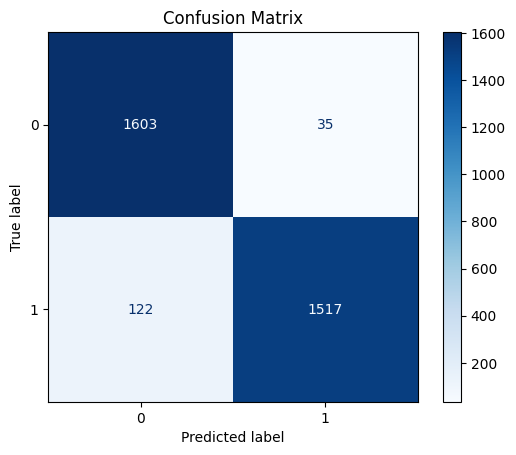

In [11]:

# 🔹 Evaluate on Test Data
y_pred = best_model.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy on Test Data:", accuracy_score(y_test, y_pred))

# 🔹 Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


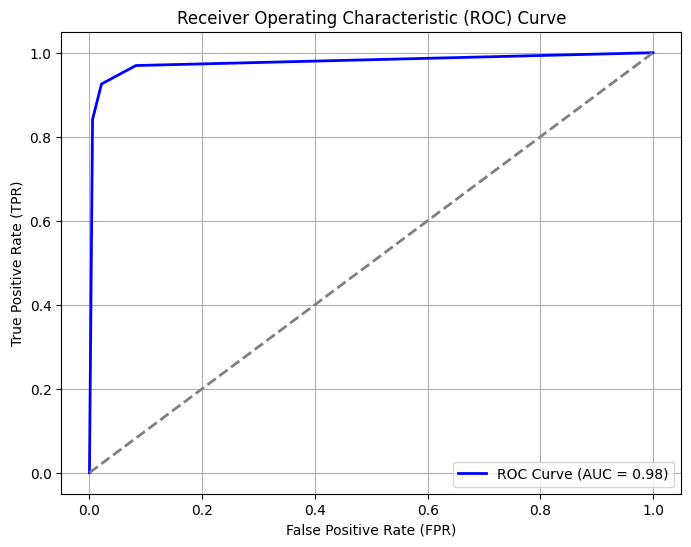

In [12]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# 🔹 ROC Curve for Test Data
y_pred_proba = best_model.predict_proba(X_test)[:, 1]  # Predicted probabilities for the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)  # Diagonal line
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid()
plt.show()


# DOMINANT FREQUENCY

In [13]:
import pandas as pd
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

In [14]:
dominant_frequency_path  = '/Users/puchku-home/Study/PROJECT/EEG/Frequency Feature  Generalised/Dominant Frequency.csv'
dadomin = pd.read_csv(dominant_frequency_path)

In [15]:
dadomin_randomized = shuffle(dadomin, random_state=42)

# 🔹 Separate Features and Target
X = dadomin.drop(columns=['target'])  # All columns except 'target' are features
y = dadomin['target']  # 'target' column is the label

# 🔹 Train-Test Split for Evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 🔹 Define KNN Pipeline with StandardScaler
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Normalize features for KNN
    ('knn', KNeighborsClassifier(n_jobs=-1))  # Multi-threaded KNN classifier
])

# 🔹 Define Hyperparameter Grid for GridSearchCV
param_grid = {
    'knn__n_neighbors': [3, 5, 7],  # Number of neighbors to consider
    'knn__weights': ['uniform', 'distance'],  # Weighting scheme
    'knn__metric': ['euclidean', 'manhattan']  # Distance metrics
}


In [16]:

# 🔹 Perform Grid Search with Cross-Validation (Inner CV Only)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),  # 5-fold CV on training set
    n_jobs=-1,
    verbose=1
)

# 🔹 Train Model and Find Best Parameters
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("\nBest Parameters from Grid Search:", grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters from Grid Search: {'knn__metric': 'manhattan', 'knn__n_neighbors': 7, 'knn__weights': 'distance'}
Best Cross-Validation Accuracy: 0.7370



Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.65      0.70      1638
           1       0.69      0.78      0.74      1639

    accuracy                           0.72      3277
   macro avg       0.72      0.72      0.72      3277
weighted avg       0.72      0.72      0.72      3277

Accuracy on Test Data: 0.718339945071712


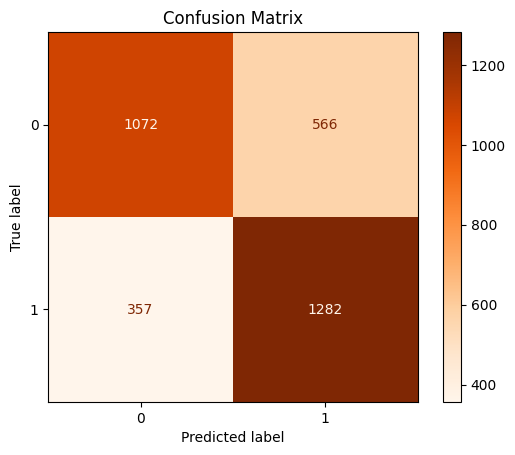

In [17]:

# 🔹 Evaluate on Test Data
y_pred = best_model.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy on Test Data:", accuracy_score(y_test, y_pred))

# 🔹 Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Oranges')
plt.title("Confusion Matrix")
plt.show()


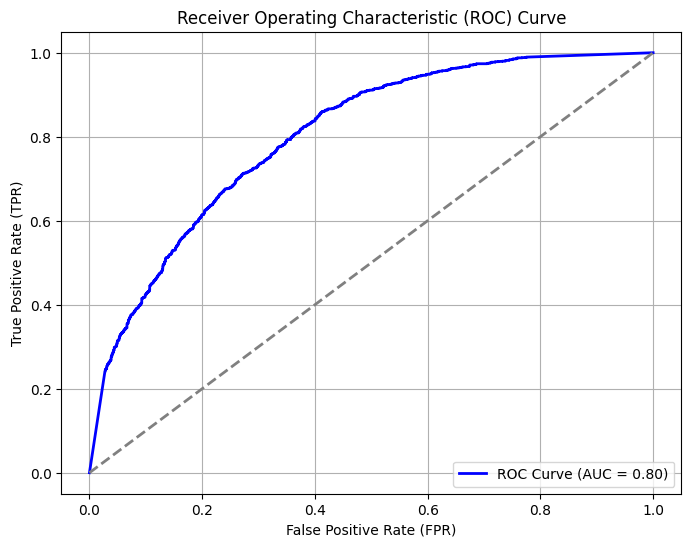

In [18]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# 🔹 ROC Curve for Test Data
y_pred_proba = best_model.predict_proba(X_test)[:, 1]  # Predicted probabilities for the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)  # Diagonal line
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid()
plt.show()


# ENTROPY


In [19]:
import pandas as pd
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

In [20]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer  # For handling NaN values as errors were poping up while going for grid search
from sklearn.neighbors import KNeighborsClassifier

In [21]:
entropy_path = '/Users/puchku-home/Study/PROJECT/EEG/Frequency Feature  Generalised/Frequency_Entropy_Features.csv'
daentropy = pd.read_csv(entropy_path)

In [22]:
daentropy_randomized = shuffle(daentropy, random_state=42)

# 🔹 Separate Features and Target
X = daentropy.drop(columns=['target'])  # All columns except 'target' are features
y = daentropy['target']  # 'target' column is the label

# 🔹 Train-Test Split for Evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 🔹 Define KNN Pipeline with Imputer and StandardScaler
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),  # Handle missing values by imputing with mean
    ('scaler', StandardScaler()),  # Normalize features for KNN
    ('knn', KNeighborsClassifier(n_jobs=-1))  # Multi-threaded KNN classifier
])

# 🔹 Define Hyperparameter Grid for GridSearchCV
param_grid = {
    'knn__n_neighbors': [3, 5, 7],  # Number of neighbors to consider
    'knn__weights': ['uniform', 'distance'],  # Weighting scheme
    'knn__metric': ['euclidean', 'manhattan']  # Distance metrics
}


In [23]:
# 🔹 Perform Grid Search with Cross-Validation (Inner CV Only)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),  # 5-fold CV on training set
    n_jobs=-1,
    verbose=1
)

# 🔹 Train Model and Find Best Parameters
grid_search.fit(X_train, y_train)  # Ensure X_train has no NaN values due to imputation in the pipeline
best_model = grid_search.best_estimator_

print("\nBest Parameters from Grid Search:", grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters from Grid Search: {'knn__metric': 'euclidean', 'knn__n_neighbors': 7, 'knn__weights': 'distance'}
Best Cross-Validation Accuracy: 0.8089



Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.81      0.81      1638
           1       0.81      0.80      0.80      1639

    accuracy                           0.80      3277
   macro avg       0.80      0.80      0.80      3277
weighted avg       0.80      0.80      0.80      3277

Accuracy on Test Data: 0.8040891058895331


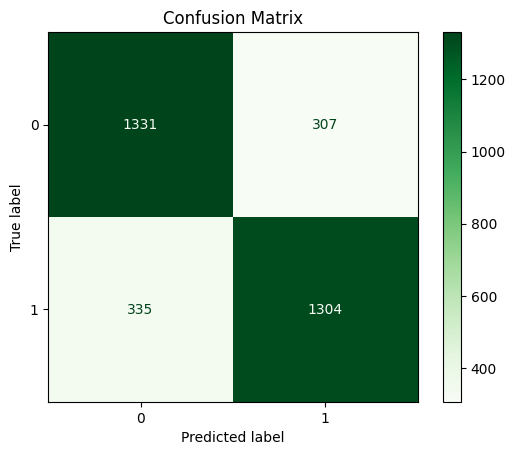

In [24]:

# 🔹 Evaluate on Test Data
y_pred = best_model.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy on Test Data:", accuracy_score(y_test, y_pred))

# 🔹 Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Greens')
plt.title("Confusion Matrix")
plt.show()


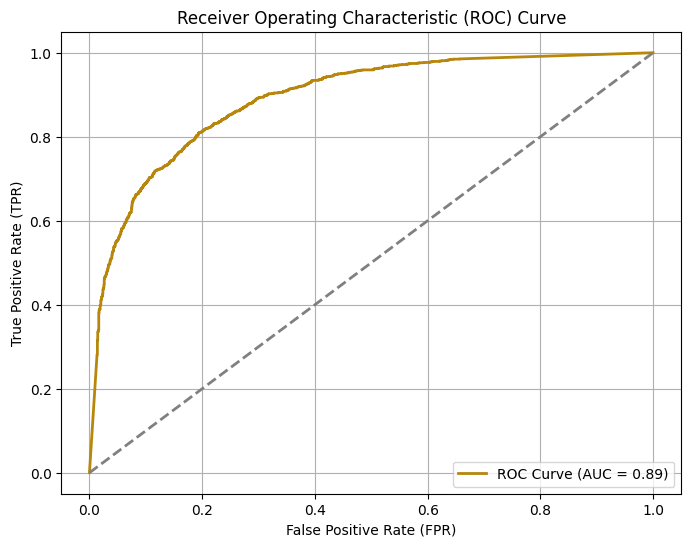

In [25]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# 🔹 ROC Curve for Test Data
y_pred_proba = best_model.predict_proba(X_test)[:, 1]  # Predicted probabilities for the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#b8860b', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)  # Diagonal line
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid()
plt.show()


# WAVELET TRANSFORM


In [26]:
import pandas as pd
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

In [27]:
wavelet_transform_path = '/Users/puchku-home/Study/PROJECT/EEG/Frequency Feature  Generalised/Wavelet_Features.csv'
dawave = pd.read_csv(wavelet_transform_path)
dawave.head(3)

,# FP1-F7_approx_mean,# FP1-F7_approx_std,# FP1-F7_approx_energy,# FP1-F7_approx_entropy,# FP1-F7_detail_mean,# FP1-F7_detail_std,# FP1-F7_detail_energy,# FP1-F7_detail_entropy,C3-P3_approx_mean,C3-P3_approx_std,...,T8-P8-0_detail_entropy,T8-P8-1_approx_mean,T8-P8-1_approx_std,T8-P8-1_approx_energy,T8-P8-1_approx_entropy,T8-P8-1_detail_mean,T8-P8-1_detail_std,T8-P8-1_detail_energy,T8-P8-1_detail_entropy,target
0,-0.000009,0.000048,8.892680e-08,3.461705,-7.834616e-07,0.000005,5.568917e-09,5.006820,0.000009,0.000033,...,4.820858,0.000016,0.000054,1.209953e-07,3.385849,-9.935179e-08,0.000004,2.996462e-09,4.820858,0
1,-0.000008,0.000039,5.943705e-08,3.325770,-8.142406e-07,0.000005,5.227323e-09,4.972393,0.000001,0.000035,...,4.827489,0.000009,0.000046,8.198123e-08,3.369617,-2.241272e-07,0.000004,3.353525e-09,4.827489,0
2,0.000003,0.000055,1.149714e-07,3.349493,-6.659446e-07,0.000005,5.248824e-09,4.968204,-0.000024,0.000026,...,4.813268,-0.000019,0.000051,1.117933e-07,3.309112,-2.189966e-07,0.000004,3.472820e-09,4.813268,0


In [28]:
dawave_randomized = shuffle(dawave, random_state=42)

# 🔹 Separate Features and Target
X = dawave.drop(columns=['target'])  # All columns except 'target' are features
y = dawave['target']  # 'target' column is the label

# 🔹 Train-Test Split for Evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 🔹 Define KNN Pipeline with StandardScaler
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Normalize features for KNN
    ('knn', KNeighborsClassifier(n_jobs=-1))  # Multi-threaded KNN classifier
])

# 🔹 Define Hyperparameter Grid for GridSearchCV
param_grid = {
    'knn__n_neighbors': [3, 5, 7],  # Number of neighbors to consider
    'knn__weights': ['uniform', 'distance'],  # Weighting scheme
    'knn__metric': ['euclidean', 'manhattan']  # Distance metrics
}


In [29]:

# 🔹 Perform Grid Search with Cross-Validation (Inner CV Only)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),  # 5-fold CV on training set
    n_jobs=-1,
    verbose=1
)

# 🔹 Train Model and Find Best Parameters
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("\nBest Parameters from Grid Search:", grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters from Grid Search: {'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}
Best Cross-Validation Accuracy: 0.9689



Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97      1638
           1       0.99      0.96      0.97      1639

    accuracy                           0.97      3277
   macro avg       0.97      0.97      0.97      3277
weighted avg       0.97      0.97      0.97      3277

Accuracy on Test Data: 0.9740616417454989


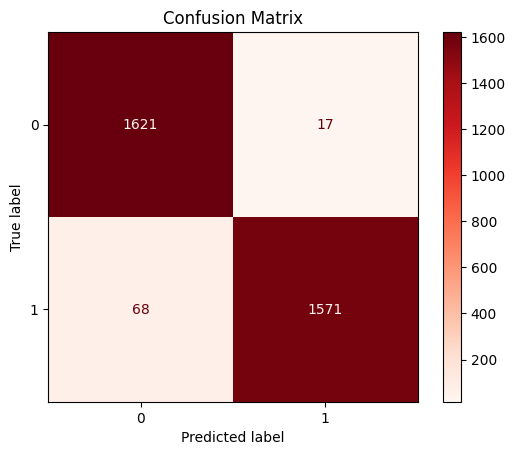

In [30]:

# 🔹 Evaluate on Test Data
y_pred = best_model.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy on Test Data:", accuracy_score(y_test, y_pred))

# 🔹 Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Reds')
plt.title("Confusion Matrix")
plt.show()


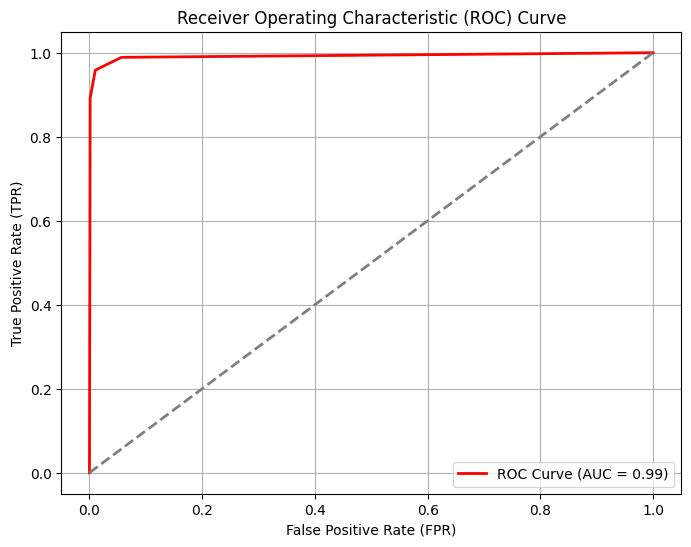

In [31]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# 🔹 ROC Curve for Test Data
y_pred_proba = best_model.predict_proba(X_test)[:, 1]  # Predicted probabilities for the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='red', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)  # Diagonal line
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid()
plt.show()
